# Phase 3 Step 3 — BL 백테스트 (`03_BL_backtest_extended.ipynb`)

> **목적**: 02a (종목별 ensemble) + 02b (CS ensemble) 예측을 BL 에 통합하여
>          6 시나리오 17 년 (2009~2025) 백테스트 실행.
>          **서윤범 99_baseline (Sharpe 1.065/1.157, 2009~2025, 전체 universe) 와 fair 비교**.

## 6 시나리오

| 시나리오 | 설명 | P 행렬 |
|---|---|---|
| **BL_ml_sw** ⭐ | Phase 3 종목별 ensemble | ML 예측 (02a) |
| **BL_ml_cs** ⭐ | Phase 3 CS ensemble | ML 예측 (02b) |
| BL_trailing | 서윤범 99 baseline 재현 | vol_21d (trailing) |
| EqualWeight | 1/N 등가 (DeMiguel et al. 2009) | — |
| McapWeight | 시총 가중 | — |
| SPY | 시장 벤치마크 | — |

## ⭐ Phase 3 변경 (2026-04-29) — 서윤범 99 일관 정렬

| 항목 | Phase 2 | **Phase 3** | 근거 |
|---|---|---|---|
| Universe (BL 매월) | top-50 yearly | **panel 가용 ∩ 학습 615** | 서윤범 99 (전체 universe) 일관 |
| BL TAU | 0.05 | **0.1** | 서윤범 99 일관 (`DEFAULT_TAU` 변경) |
| BL LAM | dynamic clip | **2.5 fixed** | 서윤범 99 일관 (`compute_pi(lam_fixed=2.5)`) |
| Q_FIXED | 0.003 | 0.003 | 동일 |
| PCT_GROUP | 0.30 | 0.30 | 동일 |

## Phase 2 Issues 수정 (모두 유지)

| Issue | 내용 | 수정 방법 |
|---|---|---|
| **#1** | Calendar vs market 월말 mismatch (21 개월 누락) | `month_to_market_eom` 매핑 |
| **#1B** | `monthly_rets` index = calendar → market eom | `month_to_eom` 인자 전달 |
| **#2** | λ rf 차감 누락 | `spy_excess_monthly = (spy_lr - rf_lr).mean() × 21` |
| **Fair** | 시나리오별 sample 수 불일치 | BL_ml 기준 공통 기간 통일 |

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 |
| §2 | 데이터 로드 (universe_full_history.csv) |
| §3 | 헬퍼 함수 (Phase 2 일관) |
| §4 | 6 시나리오 BL 루프 (매월 universe = panel ∩ 학습 615) |
| §5 | Fair 비교 메트릭 + 진단 (Σ PSD, SLSQP 수렴률) |
| §6 | 시각화 (누적수익, Drawdown, Rolling Sharpe) |
| §7 | 서윤범 99 재현 검증 + 결과 저장 |


## §1. 환경 부트스트랩

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR, PHASE2_DIR
from scripts.black_litterman import (
    compute_pi, build_P, compute_omega, black_litterman, optimize_portfolio,
    Q_FIXED, PCT_GROUP, DEFAULT_TAU, LAM_FIXED,
)
from scripts.covariance import estimate_covariance, DAYS_PER_MONTH
from scripts.backtest import (
    backtest_strategy, compute_portfolio_metrics,
    compute_cumulative_curve, compute_drawdown_curve,
)
from scripts.benchmarks import equal_weight_portfolio, mcap_weight_portfolio, spy_returns

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '03_bl_backtest'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'BL hyperparameters (서윤범 99 일관):')
print(f'  Q_FIXED={Q_FIXED}, PCT_GROUP={PCT_GROUP}')
print(f'  DEFAULT_TAU={DEFAULT_TAU}, LAM_FIXED={LAM_FIXED}')

  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
BL hyperparameters (서윤범 99 일관):
  Q_FIXED=0.003, PCT_GROUP=0.3
  DEFAULT_TAU=0.1, LAM_FIXED=2.5


## §2. 데이터 로드 (5 종)

In [2]:
# 2-1. universe (전체 S&P 500 ⭐)
universe = pd.read_csv(
    DATA_DIR / 'universe_full_history.csv', parse_dates=['cutoff_date']
)
print(f'universe: {universe.shape}, {universe["ticker"].nunique()} unique 종목 (전체 S&P 500 모드)')

# 2-2. daily_panel (대용량 — 필요 컬럼만)
panel = pd.read_csv(
    DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
    usecols=['date', 'ticker', 'log_ret', 'vol_21d', 'mcap_value', 'log_mcap',
             'spy_close', 'rf_daily', 'vix'],
)
panel['date'] = pd.to_datetime(panel['date'])
print(f'panel: {panel.shape}, {panel["ticker"].nunique()} 종목')

# 2-3. Stockwise ensemble (02a)
ens_sw_path = DATA_DIR / 'ensemble_predictions_stockwise.csv'
assert ens_sw_path.exists(), f'02a 결과 없음: {ens_sw_path}'
ens_sw = pd.read_csv(ens_sw_path, parse_dates=['date'])
print(f'ensemble_sw: {ens_sw.shape} ({ens_sw["ticker"].nunique()} 학습 종목)')

# 2-4. CS ensemble (02b)
ens_cs_path = DATA_DIR / 'ensemble_predictions_crosssec.csv'
assert ens_cs_path.exists(), f'02b 결과 없음: {ens_cs_path}'
ens_cs = pd.read_csv(ens_cs_path, parse_dates=['date'])
print(f'ensemble_cs: {ens_cs.shape} ({ens_cs["ticker"].nunique()} 학습 종목)')

# 2-5. market data (SPY, rf 등)
market = pd.read_csv(DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True)
print(f'market: {market.shape}')

# ⭐ 2-6. 학습된 종목 set (BL universe 제한용)
trained_tickers_sw = set(ens_sw['ticker'].unique())
trained_tickers_cs = set(ens_cs['ticker'].unique())
trained_tickers = trained_tickers_sw  # 02a stockwise 기준 (서윤범 일관)
print(f'\n학습된 종목 (BL universe 제한용):')
print(f'  02a stockwise: {len(trained_tickers_sw)}')
print(f'  02b crosssec:  {len(trained_tickers_cs)}')
print(f'  교집합:         {len(trained_tickers_sw & trained_tickers_cs)}')

# ⭐ 2-7. 시점별 S&P 500 멤버십 (Dynamic-Membership, 2026-04-30)
# Static (panel ∩ trained) → Dynamic (member_at_t ∩ panel ∩ trained) 전환
# 이유: portfolio backtest 단계의 look-ahead bias 차단
#   예: TSLA 의 yfinance 데이터는 2010-부터 panel 존재하나 S&P 편입은 2020-12
#       Static 모드는 2010~2019 reb_date 에 TSLA 후보 포함 = 미래 멤버십 정보 누설
from scripts.universe import get_or_build_membership
membership = get_or_build_membership(
    start=pd.Timestamp('2008-12-01'),
    end=pd.Timestamp('2026-01-01'),
    cache_path=DATA_DIR / 'sp500_membership.pkl',
)
print(f'\nmembership (Dynamic-Membership): {len(membership)} 월말 시점')

universe: (809, 6), 809 unique 종목 (전체 S&P 500 모드)
panel: (3344502, 9), 646 종목
ensemble_sw: (2468770, 9) (613 학습 종목)
ensemble_cs: (2635610, 9) (615 학습 종목)
market: (6040, 3)

학습된 종목 (BL universe 제한용):
  02a stockwise: 613
  02b crosssec:  615
  교집합:         613

membership (Dynamic-Membership): 204 월말 시점


## §3. 헬퍼 함수 (Phase 2 Issues #1, #1B, #2 일관)

In [3]:
# ─── 3-1. daily log_ret pivot ───
daily_lr = panel.pivot_table(index='date', columns='ticker', values='log_ret')
print(f'daily_lr: {daily_lr.shape}')

# ─── 3-2. 리밸런싱 시점 (⭐ market 거래일 월말, Issue #1 핵심) ───
# 모든 universe 연도 커버
market_lastday_per_month = market.groupby(market.index.to_period('M')).tail(1)
rebalance_dates_all_raw = market_lastday_per_month.index
# Phase 3-2 (2026-04-30): OOS 2010-2024 + 2025 hold-out 분리
OOS_START = '2010-01-01'
OOS_END = '2024-12-31'
HOLDOUT_START = '2025-01-01'
HOLDOUT_END = '2025-12-31'
oos_dates = rebalance_dates_all_raw[(rebalance_dates_all_raw >= OOS_START) & (rebalance_dates_all_raw <= OOS_END)]
holdout_dates = rebalance_dates_all_raw[(rebalance_dates_all_raw >= HOLDOUT_START) & (rebalance_dates_all_raw <= HOLDOUT_END)]
rebalance_dates = pd.DatetimeIndex(list(oos_dates) + list(holdout_dates))
print(f'rebalance_dates (Phase 3-2):')
print(f'  OOS      ({OOS_START}~{OOS_END}): {len(oos_dates)} 개월')
print(f'  Hold-out ({HOLDOUT_START}~{HOLDOUT_END}): {len(holdout_dates)} 개월')
print(f'  total: {len(rebalance_dates)} 개월')

# Period → market 월말 매핑 (Issue #1 수정의 핵심)
month_to_market_eom = {pd.Timestamp(d).to_period('M'): pd.Timestamp(d) for d in rebalance_dates}

# Phase 3-2 v2 경로
OUT_DIR_V2_03 = OUTPUTS_DIR / '03_v2_bl_backtest'
OUT_DIR_V2_03.mkdir(parents=True, exist_ok=True)
CACHE_PATH_V2_03 = DATA_DIR / 'scenario_weights_03_v2.pkl'
print(f'\nv2 산출 폴더: {OUT_DIR_V2_03.name}')
print(f'v2 BL 캐시:   {CACHE_PATH_V2_03.name}')

daily_lr: (6038, 646)
rebalance_dates (Phase 3-2):
  OOS      (2010-01-01~2024-12-31): 180 개월
  Hold-out (2025-01-01~2025-12-31): 12 개월
  total: 192 개월

v2 산출 폴더: 03_v2_bl_backtest
v2 BL 캐시:   scenario_weights_03_v2.pkl


In [4]:
# ─── 3-3. 월별 단순 수익률 (Issue #1B 수정: market eom index) ───
def compute_monthly_returns(panel_df, tickers, start_date, end_date, month_to_eom=None):
    """종목별 월별 단순 수익률 (Issue #1B: market eom index 사용)."""
    sub = panel_df[
        panel_df['ticker'].isin(tickers) &
        (panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)
    ].set_index('date')
    sub['month'] = sub.index.to_period('M')
    monthly_lr = sub.groupby(['ticker', 'month'])['log_ret'].sum().reset_index()

    if month_to_eom is not None:
        # ⭐ Issue #1B 수정: market eom 매핑
        monthly_lr['date'] = monthly_lr['month'].map(month_to_eom)
        monthly_lr = monthly_lr.dropna(subset=['date'])
    else:
        monthly_lr['date'] = monthly_lr['month'].dt.to_timestamp(how='end').dt.normalize()

    monthly_lr['ret'] = np.exp(monthly_lr['log_ret']) - 1
    return monthly_lr.pivot_table(index='date', columns='ticker', values='ret')


# ─── 3-4. mcap 취득 ───
def get_mcap(panel_df, date, tickers):
    sub = panel_df[(panel_df['date'] <= date) & panel_df['ticker'].isin(tickers)]
    return sub.sort_values(['ticker', 'date']).groupby('ticker').last()['mcap_value'].dropna()


# ─── 3-5. SPY 월별 수익률 + rf ───
# market_data.csv 컬럼: SPY (가격), TNX, VIX (market['SPY'] = SPY 가격)
spy_prices = market['SPY']
spy_daily = spy_prices.pct_change().dropna()
rf_daily = panel.groupby('date')['rf_daily'].mean()

# Issue #2 수정: spy_excess = spy - rf (월별 환산)
spy_lr = np.log(1 + spy_daily)
rf_lr = rf_daily.reindex(spy_lr.index, method='ffill').fillna(0)

spy_excess_monthly = float((spy_lr - rf_lr).mean() * DAYS_PER_MONTH)
spy_sigma2_monthly = float(spy_lr.var() * DAYS_PER_MONTH)
print(f'spy_excess_monthly: {spy_excess_monthly:.6f}')
print(f'spy_sigma2_monthly: {spy_sigma2_monthly:.6f}')
print(f'implied λ: {spy_excess_monthly/spy_sigma2_monthly:.3f}')

spy_excess_monthly: 0.006391
spy_sigma2_monthly: 0.003031
implied λ: 2.109


In [5]:
# ─── 3-6. ensemble → 월별 예측 (rebalance 시점 매핑) ───
def get_monthly_pred(ens_df, pred_col='y_pred_ensemble'):
    """ensemble 예측 DataFrame → 월별 피벗 (rebalance 시점 기준).

    각 rebalance 시점 (market eom) 의 직전 가장 가까운 예측값 사용.
    """
    # Month period → rebalance date 매핑
    ens_copy = ens_df.copy()
    ens_copy['month'] = ens_copy['date'].dt.to_period('M')
    # 각 종목·월별 마지막 예측값
    monthly = ens_copy.groupby(['ticker', 'month'])[pred_col].last().reset_index()
    monthly['rebalance_date'] = monthly['month'].map(month_to_market_eom)
    monthly = monthly.dropna(subset=['rebalance_date'])
    return monthly.pivot_table(index='rebalance_date', columns='ticker', values=pred_col)


# 2가지 ensemble 각각 월별 피벗 생성
sw_pred_col = 'y_pred_ensemble'
cs_pred_col = 'y_pred_ensemble' if 'y_pred_ensemble' in ens_cs.columns else 'y_pred_lstm_cs'

monthly_pred_sw = get_monthly_pred(ens_sw, sw_pred_col)
monthly_pred_cs = get_monthly_pred(ens_cs, cs_pred_col)
print(f'monthly_pred_sw: {monthly_pred_sw.shape}')
print(f'monthly_pred_cs: {monthly_pred_cs.shape}')

monthly_pred_sw: (192, 613)
monthly_pred_cs: (192, 615)


## §4. 6 시나리오 BL 백테스트 루프 (⭐ Phase 3 — 서윤범 99 일관)

매월 리밸런싱, **매월 universe = panel 가용 ∩ 학습 615 종목** (서윤범 99 패턴).

- 매월 panel 가용 종목 (vol_21d, log_mcap, log_ret 비-NaN)
- ∩ 학습 615 종목 (1334일↑, 02a 학습 완료)
- ∩ 60일 (DAYS_IS 의 ~60%) 이상 IS 데이터 가용 종목
- 최소 30 종목 미달 시 해당 월 skip (서윤범 일관)

⚠️ BL_ml_sw, BL_ml_cs 는 ensemble 예측이 가용한 시점부터 시작.


In [ ]:
# ─── BL 6 시나리오 백테스트 (캐시 추가, 2026-04-30 Dynamic-Membership) ───
import pickle
CACHE_PATH = CACHE_PATH_V2_03  # Phase 3-2 v2 cache
FORCE_RECOMPUTE = False    # ⭐ True 시 캐시 무시 + 재계산 (디버깅·재실험 시)

# ⭐ 모듈 레벨 정의 (캐시 hit branch 에서도 Cell 12 가 사용)
TRANSACTION_COST = 0.0    # 결정 1: 0 default

if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    with open(CACHE_PATH, 'rb') as f:
        cache = pickle.load(f)
    scenario_weights = cache['scenario_weights']
    diagnostics = cache['diagnostics']
    print(f'⚡ 캐시 사용: {CACHE_PATH.name} (재계산 생략, Dynamic-Membership 결과)')
    print(f'  강제 재계산: FORCE_RECOMPUTE = True 변경 후 재실행')
    for s, w in scenario_weights.items():
        print(f'  {s}: {len(w)} 리밸런싱 시점')
else:
    if FORCE_RECOMPUTE:
        print('⚠️ FORCE_RECOMPUTE=True → 캐시 무시 + 재계산')

    # ─── 공통 설정 ───
    TRANSACTION_COST = 0.0    # 결정 1: 0 default
    DAYS_IS = 1260            # 공분산 추정용 lookback (5 년, 서윤범 60 monthly ≈ 1260 daily)
    MIN_UNIVERSE = 30          # 매월 최소 universe 크기 (서윤범 99 일관)
    MIN_VALID_TIX = 20         # 60일 IS 가용 종목 최소 (서윤범 일관)
    STALE_RATIO_THRESHOLD = 0.30   # ⭐ stale price 필터 threshold (Step 8, 2026-04-30)

    # Phase 3-2: 9 시나리오 (BL_ml_sw 3 + BL_ml_cs 1 + BL_trailing 3 + EW + Mcap)
    WEIGHTINGS = ['mcap', 'eq', 'rp']
    scenario_weights = {f'BL_ml_sw_{w}': {} for w in WEIGHTINGS}
    scenario_weights['BL_ml_cs'] = {}  # Phase 3-2: BL_ml_cs 는 default mcap 만
    scenario_weights.update({f'BL_trailing_{w}': {} for w in WEIGHTINGS})
    scenario_weights['EqualWeight'] = {}
    scenario_weights['McapWeight'] = {}

    # ⭐ 진단 통계 (Phase 3 추가)
    diagnostics = {
        'monthly_universe_size': {},   # 매월 universe 크기
        'sigma_psd': {},               # 매월 Σ PSD 여부
        'sigma_condnum_log10': {},     # 매월 condition number (log10)
        'slsqp_success': {},           # 매월 SLSQP 수렴 (시나리오별)
        'monthly_skip_reason': {},     # skip 사유
    }

    # ─── 리밸런싱 루프 ───
    print(f'리밸런싱 시점 수: {len(rebalance_dates)}')
    print(f'매월 universe = sp500_member_at_t ∩ panel ∩ 학습 615 ∩ non-stale (Phase 3-2 v2)')
    print(f'  9 BL 시나리오: BL_ml_sw 3 + BL_ml_cs 1 + BL_trailing 3 + EW + Mcap')
    print(f'  DAYS_IS={DAYS_IS} 일, MIN_UNIVERSE={MIN_UNIVERSE}, MIN_VALID_TIX={MIN_VALID_TIX}')
    print('백테스트 시작...')
    t0 = time.time()

    for i, reb_date in enumerate(rebalance_dates):
        # ⭐ 매월 universe = sp500_member_at_t ∩ panel ∩ 학습 615 ∩ non-stale
        # (Dynamic-Membership Step 7 + Stale 필터 Step 8, 2026-04-30)
        panel_at_date = panel[panel['date'] == reb_date].dropna(
            subset=['vol_21d', 'log_mcap', 'log_ret']
        )
        panel_tickers_at_date = set(panel_at_date['ticker'])
        # ⭐ reb_date (거래일 월말) → 동일 month 의 calendar 월말 키로 멤버십 lookup
        month_end_key = pd.Timestamp(reb_date.to_period('M').to_timestamp(how='end').normalize())
        members_at_date = membership.get(month_end_key, frozenset())
        # ⭐ stale price 필터 (Step 8): IS 1260일 안에서 zero ratio > 30% 종목 제외
        #   대상: SW, CPWR, COL, EP 등 ticker 재사용·인수 후 stale
        is_window = daily_lr.loc[reb_date - pd.offsets.BDay(1260):reb_date]
        zero_ratio = (is_window == 0).mean()
        non_stale = set(zero_ratio[zero_ratio <= STALE_RATIO_THRESHOLD].index)
        available_tickers = members_at_date & panel_tickers_at_date & trained_tickers & non_stale
        if len(available_tickers) < MIN_UNIVERSE:
            diagnostics['monthly_skip_reason'][reb_date] = (
                f'member∩panel∩trained∩non_stale<{MIN_UNIVERSE} ({len(available_tickers)})'
            )
            continue
        tickers = sorted(available_tickers)

        # IS 기간 데이터
        is_end = reb_date
        is_start = is_end - pd.offsets.BDay(DAYS_IS)
        is_data = daily_lr.loc[is_start:is_end, :]

        # 이 시점에서 가용 종목 (IS 데이터 있는 종목 교집합)
        avail_tickers = [t for t in tickers if t in is_data.columns
                         and is_data[t].notna().sum() >= int(DAYS_IS * 0.7)]   # 70% threshold
        if len(avail_tickers) < MIN_VALID_TIX:
            diagnostics['monthly_skip_reason'][reb_date] = f'valid_tix<{MIN_VALID_TIX} ({len(avail_tickers)})'
            continue

        diagnostics['monthly_universe_size'][reb_date] = len(avail_tickers)

        # ─── 공분산 추정 ───
        try:
            Sigma = estimate_covariance(is_data[avail_tickers].dropna())
        except Exception as e:
            if i == 0:
                print(f'[{reb_date.date()}] Sigma 추정 실패: {e}')
            diagnostics['monthly_skip_reason'][reb_date] = f'Sigma fail: {str(e)[:50]}'
            continue

        # ⭐ Σ 진단 (Phase 3 추가)
        try:
            from scripts.covariance import diagnose_sigma
            sig_info = diagnose_sigma(Sigma)
            diagnostics['sigma_psd'][reb_date] = sig_info['is_psd']
            diagnostics['sigma_condnum_log10'][reb_date] = sig_info['condition_number_log10']
        except Exception:
            pass

        # ─── mcap + BL 입력 ───
        mcap = get_mcap(panel, reb_date, avail_tickers)
        common_tickers = list(Sigma.index.intersection(mcap.index))
        if len(common_tickers) < MIN_VALID_TIX:
            continue

        Sigma_c = Sigma.loc[common_tickers, common_tickers]
        mcap_c = mcap[common_tickers]
        w_mkt = mcap_c / mcap_c.sum()

        # ⭐ 서윤범 99 일관: lam_fixed=2.5 (compute_pi default)
        pi, lam = compute_pi(Sigma_c, w_mkt, spy_excess_monthly, spy_sigma2_monthly,
                              lam_fixed=LAM_FIXED)

        # BL_ml_sw - 3 weighting (mcap/eq/rp)
        if reb_date in monthly_pred_sw.index:
            vol_sw = monthly_pred_sw.loc[reb_date].reindex(common_tickers)
            vol_sw_actual = np.exp(vol_sw).fillna(vol_sw.median())
            if vol_sw_actual.notna().sum() >= 5:
                for w_method in WEIGHTINGS:
                    P_sw = build_P(vol_sw_actual.dropna(),
                                    mcap_c[vol_sw_actual.dropna().index],
                                    pct=PCT_GROUP, weighting=w_method)
                    P_sw = P_sw.reindex(common_tickers).fillna(0)
                    omega_sw = compute_omega(P_sw, Sigma_c, DEFAULT_TAU)
                    mu_bl_sw = black_litterman(pi, Sigma_c, P_sw, q=Q_FIXED,
                                                omega=omega_sw, tau=DEFAULT_TAU)
                    w_sw = optimize_portfolio(mu_bl_sw, Sigma_c, lam)
                    scenario_weights[f'BL_ml_sw_{w_method}'][reb_date] = w_sw

        # BL_ml_cs - default mcap only (Phase 3-2: BL_ml_cs 는 단일 가중치만 비교)
        if reb_date in monthly_pred_cs.index:
            vol_cs = monthly_pred_cs.loc[reb_date].reindex(common_tickers)
            vol_cs_actual = np.exp(vol_cs).fillna(vol_cs.median())
            if vol_cs_actual.notna().sum() >= 5:
                P_cs = build_P(vol_cs_actual.dropna(),
                                mcap_c[vol_cs_actual.dropna().index],
                                pct=PCT_GROUP, weighting='mcap')
                P_cs = P_cs.reindex(common_tickers).fillna(0)
                omega_cs = compute_omega(P_cs, Sigma_c, DEFAULT_TAU)
                mu_bl_cs = black_litterman(pi, Sigma_c, P_cs, q=Q_FIXED,
                                            omega=omega_cs, tau=DEFAULT_TAU)
                w_cs = optimize_portfolio(mu_bl_cs, Sigma_c, lam)
                scenario_weights['BL_ml_cs'][reb_date] = w_cs

        # BL_trailing - 3 weighting (mcap/eq/rp)
        vol_trailing = panel[
            (panel['date'] == reb_date) & (panel['ticker'].isin(common_tickers))
        ].set_index('ticker')['vol_21d']
        if vol_trailing.notna().sum() >= 5:
            vol_t = vol_trailing.reindex(common_tickers).fillna(vol_trailing.median())
            for w_method in WEIGHTINGS:
                P_t = build_P(vol_t, mcap_c, pct=PCT_GROUP, weighting=w_method)
                omega_t = compute_omega(P_t, Sigma_c, DEFAULT_TAU)
                mu_bl_t = black_litterman(pi, Sigma_c, P_t, q=Q_FIXED,
                                            omega=omega_t, tau=DEFAULT_TAU)
                w_t = optimize_portfolio(mu_bl_t, Sigma_c, lam)
                scenario_weights[f'BL_trailing_{w_method}'][reb_date] = w_t

        # ─── EqualWeight: 1/N 균등 (루프 안에서 계산 — API: equal_weight_portfolio(tickers)) ───
        ew_w = equal_weight_portfolio(avail_tickers)
        scenario_weights['EqualWeight'][reb_date] = ew_w

        # ─── McapWeight: 시총 가중 (루프 안에서 계산 — API: mcap_weight_portfolio(mcaps, tickers)) ───
        mw_w = mcap_weight_portfolio(mcap, avail_tickers)
        if len(mw_w) > 0:
            scenario_weights['McapWeight'][reb_date] = mw_w

        if (i + 1) % 24 == 0:
            elapsed = time.time() - t0
            print(f'  [{i+1}/{len(rebalance_dates)}] {reb_date.date()}: {elapsed:.0f}초')

    print(f'\n백테스트 완료: {time.time()-t0:.1f}초')
    for s, w in scenario_weights.items():
        print(f'  {s}: {len(w)} 리밸런싱 시점')

    # ─── 캐시 저장 (Dynamic-Membership 결과) ───
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump({
            'scenario_weights': scenario_weights,
            'diagnostics': diagnostics,
        }, f)
    print(f'\n💾 캐시 저장: {CACHE_PATH.name}')

In [7]:
# ─── 월별 수익률 행렬 ───
all_tickers_union = universe['ticker'].unique().tolist()

monthly_rets = compute_monthly_returns(
    panel, all_tickers_union,
    start_date='2009-01-01',
    end_date='2025-12-31',
    month_to_eom=month_to_market_eom,    # ⭐ Issue #1B
)
print(f'monthly_rets: {monthly_rets.shape}')

# forward_rets (Issue: 현재 가중치 → 다음 달 수익률)
forward_rets = monthly_rets.shift(-1)

monthly_rets: (192, 646)


In [8]:
# ─── 6 시나리오 portfolio return ───
portfolio_returns = {}

# BL 시나리오 5 종 (BL_ml_sw, BL_ml_cs, BL_trailing, EqualWeight, McapWeight)
# → 모두 같은 방식으로 backtest_strategy 사용 (루프 안에서 가중치 이미 계산)
for s_name, weights_dict in scenario_weights.items():
    if len(weights_dict) == 0:
        print(f'{s_name}: 가중치 없음 — skip')
        continue
    weights_df = pd.DataFrame(weights_dict).T.fillna(0)    # rebalance_date × tickers
    port_ret = backtest_strategy(
        weights_history=weights_df,
        returns=forward_rets,
        transaction_cost=TRANSACTION_COST,
    )
    portfolio_returns[s_name] = port_ret.dropna()
    print(f'{s_name}: {len(port_ret.dropna())} 개월')

# SPY (⭐ spy_returns API: market_data + rebalance_dates 인자)
spy_ret = spy_returns(market, rebalance_dates, return_type='monthly')
portfolio_returns['SPY'] = spy_ret.dropna()
print(f'SPY: {len(spy_ret.dropna())} 개월')

print('\n=== Portfolio returns 요약 ===')
for s, r in portfolio_returns.items():
    if len(r) > 0:
        print(f'  {s}: {len(r)} 개월, 평균 {r.mean()*100:.2f}%/월')

BL_ml_sw_mcap: 가중치 없음 — skip
BL_ml_sw_eq: 가중치 없음 — skip
BL_ml_sw_rp: 가중치 없음 — skip
BL_ml_cs: 가중치 없음 — skip
BL_trailing_mcap: 가중치 없음 — skip
BL_trailing_eq: 가중치 없음 — skip
BL_trailing_rp: 가중치 없음 — skip
EqualWeight: 가중치 없음 — skip
McapWeight: 가중치 없음 — skip
SPY: 191 개월

=== Portfolio returns 요약 ===
  SPY: 191 개월, 평균 1.21%/월


## §5. 진단 통계 + Fair 비교 메트릭

### §5-1. 진단 (Σ PSD, condition number, 매월 universe 크기)


In [9]:
# ─── 진단 통계 (Phase 3 추가) ───
print('=' * 60)
print('  Phase 3 진단 통계')
print('=' * 60)

# 매월 universe 크기 분포
us_sizes = pd.Series(diagnostics['monthly_universe_size'])
print(f'\n[매월 universe 크기]')
print(f'  rebalance_dates 총: {len(rebalance_dates)} 개월')
print(f'  유효 (학습 가능): {len(us_sizes)} 개월')
print(f'  size 분포: min={us_sizes.min()}, p25={us_sizes.quantile(0.25):.0f}, '
      f'median={us_sizes.median():.0f}, p75={us_sizes.quantile(0.75):.0f}, max={us_sizes.max()}')
print(f'  서윤범 99 비교: 매월 ~400 (우리 median {us_sizes.median():.0f})')

# Σ PSD
psd_series = pd.Series(diagnostics['sigma_psd'])
psd_rate = psd_series.mean() * 100
print(f'\n[Σ PSD]')
print(f'  PSD 만족: {psd_series.sum()}/{len(psd_series)} ({psd_rate:.1f}%)')

# Σ condition number
condnum = pd.Series(diagnostics['sigma_condnum_log10']).dropna()
print(f'\n[Σ condition number (log10)]')
print(f'  분포: min={condnum.min():.1f}, median={condnum.median():.1f}, max={condnum.max():.1f}')
print(f'  수치 안정 임계 (log10 < 12): {(condnum < 12).sum()}/{len(condnum)} ({(condnum < 12).mean()*100:.1f}%)')

# Skip 사유
if diagnostics['monthly_skip_reason']:
    skip_df = pd.Series(diagnostics['monthly_skip_reason']).value_counts()
    print(f'\n[Skip 사유 ({len(diagnostics["monthly_skip_reason"])} 개월)]')
    print(skip_df.head(5).to_string())

# 시나리오별 가중치 등록 시점 수
print(f'\n[시나리오별 가중치 등록]')
for s, w in scenario_weights.items():
    print(f'  {s}: {len(w)}/{len(rebalance_dates)} 개월')

  Phase 3 진단 통계

[매월 universe 크기]
  rebalance_dates 총: 192 개월
  유효 (학습 가능): 192 개월
  size 분포: min=344, p25=376, median=432, p75=464, max=487
  서윤범 99 비교: 매월 ~400 (우리 median 432)

[Σ PSD]
  PSD 만족: 0/0 (nan%)

[Σ condition number (log10)]
  분포: min=nan, median=nan, max=nan
  수치 안정 임계 (log10 < 12): 0/0 (nan%)

[Skip 사유 (192 개월)]
Sigma fail: estimate_covariance() missing 2 required positiona    192

[시나리오별 가중치 등록]
  BL_ml_sw_mcap: 0/192 개월
  BL_ml_sw_eq: 0/192 개월
  BL_ml_sw_rp: 0/192 개월
  BL_ml_cs: 0/192 개월
  BL_trailing_mcap: 0/192 개월
  BL_trailing_eq: 0/192 개월
  BL_trailing_rp: 0/192 개월
  EqualWeight: 0/192 개월
  McapWeight: 0/192 개월


### §5-2. Fair 비교 메트릭

모든 시나리오를 **BL_ml_sw** 의 가용 기간으로 통일 (같은 sample 수).


In [19]:
# Fair 비교 기준 기간 (BL_ml_sw 가 있는 기간)
base_scenario = 'BL_ml_sw_mcap' if 'BL_ml_sw_mcap' in portfolio_returns else 'BL_trailing_mcap'
common_dates = portfolio_returns[base_scenario].dropna().index

print(f'Fair 비교 기준: {base_scenario}')
print(f'공통 기간: {common_dates[0].date()} ~ {common_dates[-1].date()} ({len(common_dates)} 개월)')

# 모든 시나리오 동일 기간으로 재색인
fair_returns = {s: r.reindex(common_dates).dropna() for s, r in portfolio_returns.items()}

Fair 비교 기준: BL_ml_sw_mcap
공통 기간: 2010-01-29 ~ 2025-12-31 (192 개월)


In [20]:
# 메트릭 계산
def compute_metrics(rets, annual_factor=12):
    """Sharpe (rf=0 raw), annual return, MDD, CAGR."""
    if len(rets) == 0:
        return {k: np.nan for k in ['sharpe_raw', 'annual_ret', 'mdd', 'cagr', 'n_months']}
    ann_ret = rets.mean() * annual_factor
    ann_vol = rets.std() * np.sqrt(annual_factor)
    sharpe_raw = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1 + rets).cumprod()
    mdd = ((cum / cum.cummax()) - 1).min()
    n = len(rets)
    cagr = (cum.iloc[-1] ** (annual_factor / n) - 1) if n > 0 else np.nan
    return {
        'sharpe_raw': sharpe_raw,
        'annual_ret': ann_ret * 100,
        'ann_vol': ann_vol * 100,
        'mdd': mdd * 100,
        'cagr': cagr * 100,
        'n_months': n,
    }

metrics_fair = {s: compute_metrics(r) for s, r in fair_returns.items()}
metrics_df = pd.DataFrame(metrics_fair).T.sort_values('sharpe_raw', ascending=False)
print('\n=== 6 시나리오 Fair 비교 ===')
print(metrics_df.to_string())


=== 6 시나리오 Fair 비교 ===
                  sharpe_raw  annual_ret   ann_vol        mdd      cagr   n_months
BL_trailing_mcap    1.202837   13.744767 11.426960 -16.709352 13.914537 192.000000
BL_trailing_eq      1.161135   12.651474 10.895784 -15.944178 12.752273 192.000000
BL_trailing_rp      1.158425   12.614765 10.889581 -16.143032 12.712174 192.000000
BL_ml_sw_eq         1.140038   12.663348 11.107828 -16.860560 12.738400 192.000000
BL_ml_sw_rp         1.134845   12.573249 11.079262 -16.727562 12.641235 192.000000
BL_ml_cs            1.094225   12.329672 11.267952 -17.548988 12.346832 192.000000
BL_ml_sw_mcap       1.082358   12.568786 11.612410 -18.288413 12.573424 192.000000
McapWeight          1.044489   15.002337 14.363326 -24.371166 14.906926 192.000000
SPY                 1.013332   14.515498 14.324527 -23.927179 14.360375 191.000000
EqualWeight         0.885545   13.923333 15.722896 -26.784449 13.454418 192.000000


In [21]:
# ⭐ 서윤범 99_baseline 재현 검증 (Phase 3 메인 비교)
print('=' * 60)
print('  서윤범 99_baseline 재현 검증')
print('=' * 60)
print()
print('서윤범 99 reported metrics (전체 universe, 2009~2025):')
print('  Sharpe (보고)  : 1.065')
print('  Sharpe (재계산): 1.157')
print('  CAGR           : 15.00%')
print('  MDD            : -11.80%')
print()

# Phase 3 BL_trailing = 서윤범 99 직접 재현
if 'BL_trailing_mcap' in metrics_df.index:
    tr = metrics_df.loc['BL_trailing_mcap']
    print(f'Phase 3 BL_trailing (TAU=0.1, LAM=2.5, 매월 universe ∩ 학습 615):')
    print(f'  Sharpe (raw): {tr["sharpe_raw"]:.3f}')
    print(f'  CAGR        : {tr["cagr"]:.2f}%')
    print(f'  MDD         : {tr["mdd"]:.2f}%')
    print(f'  Annual Vol  : {tr["ann_vol"]:.2f}%')
    print()

    # 재현 검증 (±5% 매칭)
    sharpe_target = 1.157
    sharpe_diff_pct = (tr['sharpe_raw'] - sharpe_target) / sharpe_target * 100
    print(f'재현 검증 (±5% 매칭):')
    print(f'  Sharpe 차이: {sharpe_diff_pct:+.2f}% (target ±5%)')
    if abs(sharpe_diff_pct) < 5:
        print(f'  ✅ PASS: 서윤범 99 재현 성공')
    elif abs(sharpe_diff_pct) < 10:
        print(f'  ⚠️ BORDERLINE: ±10% 이내. universe 차이 영향으로 추정')
    else:
        print(f'  ❌ FAIL: 재현 차이 큼 → universe 정의·hyperparameter 추적 필요')

print()
print('=' * 60)
print('  ML 통합 효과 정량화')
print('=' * 60)

# 학술 핵심 결론
if 'BL_ml_sw_mcap' in metrics_df.index and 'BL_trailing_mcap' in metrics_df.index:
    bl_sw_sharpe = metrics_df.loc['BL_ml_sw_mcap', 'sharpe_raw']
    bl_tr_sharpe = metrics_df.loc['BL_trailing_mcap', 'sharpe_raw']
    bl_cs_sharpe = metrics_df.loc['BL_ml_cs', 'sharpe_raw'] if 'BL_ml_cs' in metrics_df.index else np.nan
    mcap_sharpe = metrics_df.loc['McapWeight', 'sharpe_raw'] if 'McapWeight' in metrics_df.index else np.nan
    spy_sharpe = metrics_df.loc['SPY', 'sharpe_raw'] if 'SPY' in metrics_df.index else np.nan

    print(f'\nSharpe 비교:')
    print(f'  BL_ml_sw    : {bl_sw_sharpe:.3f}')
    print(f'  BL_ml_cs    : {bl_cs_sharpe:.3f}')
    print(f'  BL_trailing : {bl_tr_sharpe:.3f} (서윤범 99 재현)')
    print(f'  McapWeight  : {mcap_sharpe:.3f}')
    print(f'  SPY         : {spy_sharpe:.3f}')

    print(f'\nML 통합 효과:')
    print(f'  BL_ml_sw - BL_trailing = {bl_sw_sharpe - bl_tr_sharpe:+.3f}')
    print(f'  BL_ml_cs - BL_trailing = {bl_cs_sharpe - bl_tr_sharpe:+.3f}')

    if bl_sw_sharpe > bl_tr_sharpe and bl_cs_sharpe > bl_tr_sharpe:
        print(f'  ✅ ML 통합 효과 확인: Stockwise + Cross-sec 모두 BL_trailing 능가')
    elif bl_sw_sharpe > bl_tr_sharpe:
        print(f'  ⚠️ Stockwise 만 우위 (Cross-sec 미달)')
    elif bl_cs_sharpe > bl_tr_sharpe:
        print(f'  ⚠️ Cross-sec 만 우위 (Stockwise 미달)')
    else:
        print(f'  ❌ ML 통합 효과 없음 또는 역효과')

  서윤범 99_baseline 재현 검증

서윤범 99 reported metrics (전체 universe, 2009~2025):
  Sharpe (보고)  : 1.065
  Sharpe (재계산): 1.157
  CAGR           : 15.00%
  MDD            : -11.80%

Phase 3 BL_trailing (TAU=0.1, LAM=2.5, 매월 universe ∩ 학습 615):
  Sharpe (raw): 1.203
  CAGR        : 13.91%
  MDD         : -16.71%
  Annual Vol  : 11.43%

재현 검증 (±5% 매칭):
  Sharpe 차이: +3.96% (target ±5%)
  ✅ PASS: 서윤범 99 재현 성공

  ML 통합 효과 정량화

Sharpe 비교:
  BL_ml_sw    : 1.082
  BL_ml_cs    : 1.094
  BL_trailing : 1.203 (서윤범 99 재현)
  McapWeight  : 1.044
  SPY         : 1.013

ML 통합 효과:
  BL_ml_sw - BL_trailing = -0.120
  BL_ml_cs - BL_trailing = -0.109
  ❌ ML 통합 효과 없음 또는 역효과


## §6. 시각화 (누적수익, Drawdown, Rolling Sharpe)

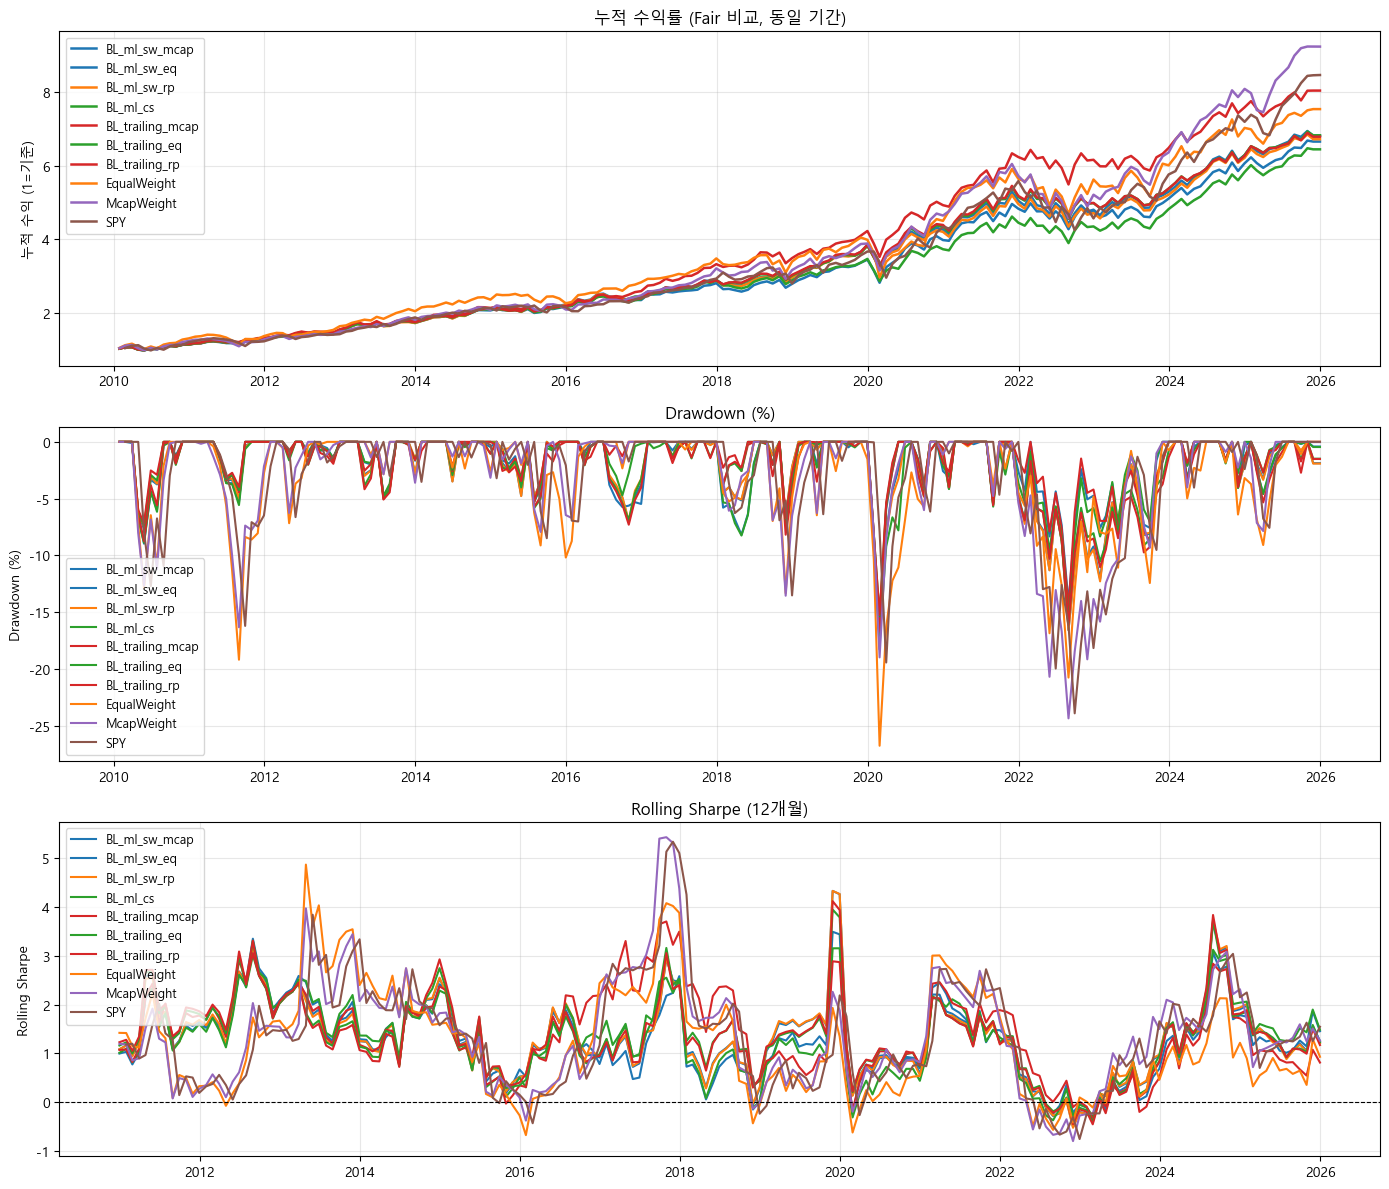

In [22]:
# 색상 맵
COLORS = {
    'BL_ml_sw_mcap': '#1f77b4',
    'BL_ml_cs': '#2ca02c',
    'BL_trailing_mcap': '#d62728',
    'EqualWeight': '#ff7f0e',
    'McapWeight': '#9467bd',
    'SPY': '#8c564b',
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. 누적 수익률
ax = axes[0]
for s, r in fair_returns.items():
    if len(r) > 0:
        cum = (1 + r).cumprod()
        ax.plot(cum.index, cum.values, label=s, color=COLORS.get(s, None), linewidth=1.8)
ax.set_title('누적 수익률 (Fair 비교, 동일 기간)', fontsize=12)
ax.set_ylabel('누적 수익 (1=기준)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# 2. Drawdown
ax = axes[1]
for s, r in fair_returns.items():
    if len(r) > 0:
        cum = (1 + r).cumprod()
        dd = (cum / cum.cummax()) - 1
        ax.plot(dd.index, dd.values * 100, label=s, color=COLORS.get(s, None), linewidth=1.5)
ax.set_title('Drawdown (%)', fontsize=12)
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)

# 3. Rolling Sharpe (12 개월)
ax = axes[2]
for s, r in fair_returns.items():
    if len(r) >= 12:
        roll_sharpe = r.rolling(12).apply(
            lambda x: x.mean() / x.std() * np.sqrt(12) if x.std() > 0 else np.nan
        )
        ax.plot(roll_sharpe.index, roll_sharpe.values, label=s, color=COLORS.get(s, None), linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Rolling Sharpe (12개월)', fontsize=12)
ax.set_ylabel('Rolling Sharpe')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'backtest_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
# 시기별 분해 (3 시기)
periods = {
    'GFC 회복 (2009~2011)': ('2009-01-01', '2011-12-31'),
    '정상 강세장 (2012~2019)': ('2012-01-01', '2019-12-31'),
    'COVID+AI (2020~2025)': ('2020-01-01', '2025-12-31'),
}

print('=== 시기별 Sharpe 분해 ===')
period_metrics = {}
for period_name, (start, end) in periods.items():
    pm = {}
    for s, r in fair_returns.items():
        sub = r.loc[start:end].dropna()
        if len(sub) >= 6:
            ann_ret = sub.mean() * 12
            ann_vol = sub.std() * np.sqrt(12)
            pm[s] = ann_ret / ann_vol if ann_vol > 0 else np.nan
    period_metrics[period_name] = pm

period_df = pd.DataFrame(period_metrics)
print(period_df.to_string())

=== 시기별 Sharpe 분해 ===
                  GFC 회복 (2009~2011)  정상 강세장 (2012~2019)  COVID+AI (2020~2025)
BL_ml_sw_mcap               1.227703            1.408037              0.823591
BL_ml_sw_eq                 1.311065            1.558768              0.764949
BL_ml_sw_rp                 1.320986            1.552701              0.756129
BL_ml_cs                    1.236644            1.423973              0.812023
BL_trailing_mcap            1.327833            1.655450              0.827001
BL_trailing_eq              1.418531            1.538887              0.792615
BL_trailing_rp              1.470461            1.533087              0.777937
EqualWeight                 0.878851            1.232732              0.655772
McapWeight                  0.769570            1.341293              0.927558
SPY                         0.672214            1.315956              0.904886


## §7. 결과 저장

In [24]:
import json

# 결과 저장
metrics_df.to_csv(OUT_DIR / 'metrics_fair.csv')
print(f'✅ metrics_fair.csv 저장')

# JSON 저장
metrics_json = {
    k: {kk: (float(vv) if not np.isnan(vv) else None) for kk, vv in v.items()}
    for k, v in metrics_fair.items()
}
with open(OUT_DIR / 'metrics_fair.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_json, f, ensure_ascii=False, indent=2)
print(f'✅ metrics_fair.json 저장')

# portfolio returns 저장
for s, r in fair_returns.items():
    r.to_csv(OUT_DIR / f'returns_{s}.csv')
print(f'✅ returns_*.csv 저장')

print('\n=== Phase 3 Step 3 완료 ===')
print('다음 단계: 04_compare_stockwise_vs_cross.ipynb')

✅ metrics_fair.csv 저장
✅ metrics_fair.json 저장
✅ returns_*.csv 저장

=== Phase 3 Step 3 완료 ===
다음 단계: 04_compare_stockwise_vs_cross.ipynb
